<img src="https://www.mmu.edu.my/fci/wp-content/uploads/2021/01/FCI_wNEW_MMU_LOGO.png" style="height: 80px;" align=left>  

## Project Proposal
#### Lecture Session: TC2L | Tutorial Section: TT5L
#### Group P79 Member :
1. Ng Xhun Yan (251UC250X9)
2. Koh Soon Keat (251UC250F2)
3. Tan Kim Hian (251UC250C2)
4. Wong Yan Sheng (251UC250C6)

### Import all necessary libraries for analysis


In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

import warnings
import logging
import os

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import pickle


### Importing the dataset into dataframe

In [36]:
# Reading the dataset into pandas dataframe
path = os.getcwd() + '/heart_2022_no_nans.csv'
Heart = pd.read_csv(path)
print("Rows, Columns:", Heart.shape)
display(Heart.head(5))
Heart.info()

Rows, Columns: (246022, 40)


,State,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,HadHeartAttack,...,HeightInMeters,WeightInKilograms,BMI,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,Alabama,Female,Very good,4.0,0.0,Within past year (anytime less than 12 months ...,Yes,9.0,None of them,No,...,1.60,71.67,27.99,No,No,Yes,Yes,"Yes, received Tdap",No,No
1,Alabama,Male,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,6.0,None of them,No,...,1.78,95.25,30.13,No,No,Yes,Yes,"Yes, received tetanus shot but not sure what type",No,No
2,Alabama,Male,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,No,8.0,"6 or more, but not all",No,...,1.85,108.86,31.66,Yes,No,No,Yes,"No, did not receive any tetanus shot in the pa...",No,Yes
3,Alabama,Female,Fair,5.0,0.0,Within past year (anytime less than 12 months ...,Yes,9.0,None of them,No,...,1.70,90.72,31.32,No,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,Yes
4,Alabama,Female,Good,3.0,15.0,Within past year (anytime less than 12 months ...,Yes,5.0,1 to 5,No,...,1.55,79.38,33.07,No,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,No


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246022 entries, 0 to 246021
Data columns (total 40 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   State                      246022 non-null  object 
 1   Sex                        246022 non-null  object 
 2   GeneralHealth              246022 non-null  object 
 3   PhysicalHealthDays         246022 non-null  float64
 4   MentalHealthDays           246022 non-null  float64
 5   LastCheckupTime            246022 non-null  object 
 6   PhysicalActivities         246022 non-null  object 
 7   SleepHours                 246022 non-null  float64
 8   RemovedTeeth               246022 non-null  object 
 9   HadHeartAttack             246022 non-null  object 
 10  HadAngina                  246022 non-null  object 
 11  HadStroke                  246022 non-null  object 
 12  HadAsthma                  246022 non-null  object 
 13  HadSkinCancer              24

### Exploratory Data Analysis
This step is to find out the data statistics and the necessary steps to clean up the data such as removal of duplicate records, handling missing values and data encoding.

In [37]:
Heart.isnull().sum()

State                        0
Sex                          0
GeneralHealth                0
PhysicalHealthDays           0
MentalHealthDays             0
LastCheckupTime              0
PhysicalActivities           0
SleepHours                   0
RemovedTeeth                 0
HadHeartAttack               0
HadAngina                    0
HadStroke                    0
HadAsthma                    0
HadSkinCancer                0
HadCOPD                      0
HadDepressiveDisorder        0
HadKidneyDisease             0
HadArthritis                 0
HadDiabetes                  0
DeafOrHardOfHearing          0
BlindOrVisionDifficulty      0
DifficultyConcentrating      0
DifficultyWalking            0
DifficultyDressingBathing    0
DifficultyErrands            0
SmokerStatus                 0
ECigaretteUsage              0
ChestScan                    0
RaceEthnicityCategory        0
AgeCategory                  0
HeightInMeters               0
WeightInKilograms            0
BMI     

### Displaying the count of unique entry in each feature.
The state feature is dropped as it is not important for this analysis. The analysis focuses on the behavior and preexisting condition to predict the risk of getting heart disease.

In [38]:
display(Heart.nunique())
Heart = Heart.drop(columns=['State'])

State                          54
Sex                             2
GeneralHealth                   5
PhysicalHealthDays             31
MentalHealthDays               31
LastCheckupTime                 4
PhysicalActivities              2
SleepHours                     23
RemovedTeeth                    4
HadHeartAttack                  2
HadAngina                       2
HadStroke                       2
HadAsthma                       2
HadSkinCancer                   2
HadCOPD                         2
HadDepressiveDisorder           2
HadKidneyDisease                2
HadArthritis                    2
HadDiabetes                     4
DeafOrHardOfHearing             2
BlindOrVisionDifficulty         2
DifficultyConcentrating         2
DifficultyWalking               2
DifficultyDressingBathing       2
DifficultyErrands               2
SmokerStatus                    4
ECigaretteUsage                 4
ChestScan                       2
RaceEthnicityCategory           5
AgeCategory   

### Displaying the distribution of the dataset
The distribution below discover some fundamental statistics of the dataset. It is crucial to do so for fundamental understanding of the dataset.

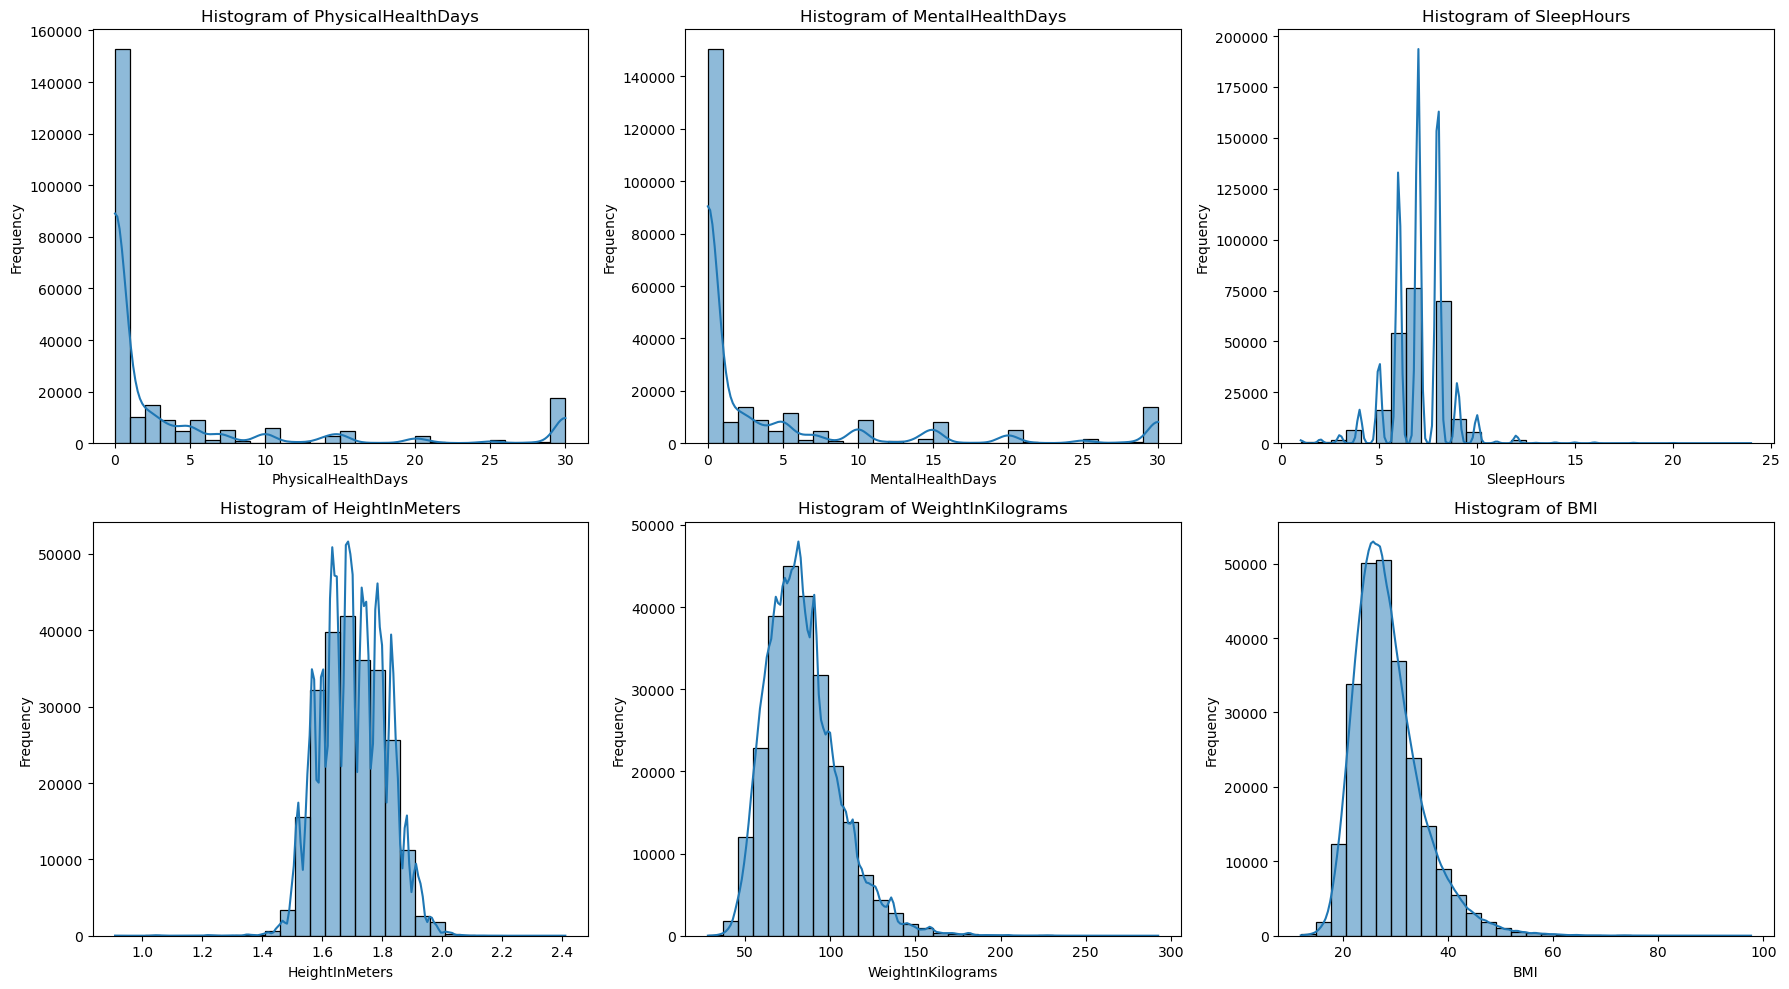

In [39]:
# Identify numerical columns
numerical_cols = Heart.select_dtypes(include=['float64', 'int64']).columns

# Number of plots
n_cols = 3
n_rows = math.ceil(len(numerical_cols) / n_cols)

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()  # Flatten for easy indexing

# Plot each histogram
for i, col in enumerate(numerical_cols):
    sns.histplot(Heart[col], kde=True, bins=30, ax=axes[i])
    axes[i].set_title(f'Histogram of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Remove empty subplots (if any)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


### Removing Duplicate Records

Duplicate records may introduce bias and distort model learning.  
All duplicate rows were identified and removed to ensure data integrity and prevent redundancy.


In [40]:
Heart.duplicated().sum()

np.int64(36)

In [41]:
Heart = Heart.drop_duplicates()
Heart.duplicated().sum()

np.int64(0)

### Data Balancing

The feature of HadHeartAttack has a big difference between its recorded boolean entry. It is important that the imbalance is handled properly to have an accurate analysis and machine learning. The imbalance is handled by randomly sample the oversampled feature to meet the shape of the undersampled feature.

In [42]:
Heart.head()
Heart.shape


(245986, 39)

In [43]:
Heart['HadHeartAttack'].sum()
Heart['HadHeartAttack'].value_counts()

HadHeartAttack
No     232551
Yes     13435
Name: count, dtype: int64

In [44]:
# Separating the healthy and had heart attack history
df_healthy = Heart[Heart['HadHeartAttack'] == 'No']
df_disease = Heart[Heart['HadHeartAttack'] == 'Yes']
print(f"Dataframe shape for healthy: {df_healthy.shape}")
print(f"Dataframe shape for disease: {df_disease.shape}")

Dataframe shape for healthy: (232551, 39)
Dataframe shape for disease: (13435, 39)


In [45]:
df_balanced = pd.concat([
    df_disease,
    df_healthy.sample(n=df_disease.shape[0], random_state=42)
    ])
print(f"Shape of balanced dataset: {df_balanced.shape}")
print(f"Row count of healthy in balanced dataset: {(df_balanced['HadHeartAttack'] == 'No').sum()}")
print(f"Row count of disease in balanced dataset: {(df_balanced['HadHeartAttack'] == 'Yes').sum()}")
df_balanced.head()

Shape of balanced dataset: (26870, 39)
Row count of healthy in balanced dataset: 13435
Row count of disease in balanced dataset: 13435


,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,HadHeartAttack,HadAngina,...,HeightInMeters,WeightInKilograms,BMI,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
7,Male,Fair,5.0,0.0,Within past year (anytime less than 12 months ...,Yes,8.0,1 to 5,Yes,Yes,...,1.75,74.84,24.37,No,Yes,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,Yes
12,Male,Good,5.0,0.0,Within past year (anytime less than 12 months ...,Yes,5.0,"6 or more, but not all",Yes,No,...,1.88,115.67,32.74,No,No,Yes,Yes,"Yes, received tetanus shot but not sure what type",No,No
34,Male,Good,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,6.0,1 to 5,Yes,Yes,...,1.78,71.67,22.67,No,No,Yes,Yes,"Yes, received Tdap",No,No
37,Male,Good,3.0,27.0,Within past year (anytime less than 12 months ...,Yes,5.0,"6 or more, but not all",Yes,Yes,...,1.85,123.83,36.02,No,No,Yes,No,"Yes, received tetanus shot but not sure what type",No,Yes
43,Male,Good,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,8.0,1 to 5,Yes,Yes,...,1.78,95.25,30.13,No,Yes,Yes,Yes,"Yes, received tetanus shot but not sure what type",No,No


### Categorical Feature Encoding
Categorical variables are converted into numerical format using one-hot encoding.  
The `drop_first=True` parameter is applied to avoid multicollinearity by removing one redundant dummy variable from each categorical feature.

In [46]:
Categorical_cols = df_balanced.select_dtypes(include=["object"]).columns
for col in Categorical_cols:
    df_balanced[col] = df_balanced[col].str.strip().str.title()

### To check for BMI and to convert it into categorical column

In [47]:
df_balanced['BMI'].describe()

count    26870.000000
mean        29.076369
std          6.538292
min         12.340000
25%         24.680000
50%         28.060000
75%         32.280000
max         95.660000
Name: BMI, dtype: float64

In [48]:
# Categorizing BMI
max_bmi = df_balanced['BMI'].max()
df_balanced['BMI_Cat'] = pd.cut(
    df_balanced['BMI'],
    bins = [0, 18.5, 25, 30, max_bmi],
    labels = ['Underweight', 'Normal', 'Overweight', 'Obese']
)
df_balanced['BMI_Cat'].value_counts()


BMI_Cat
Obese          9895
Overweight     9721
Normal         6842
Underweight     412
Name: count, dtype: int64

### Converting Sleep Hour into Categorical Data

In [49]:

df_balanced['SleepHours_Cat'] = pd.cut(
    df_balanced['SleepHours'],
    bins = [0, 7, df_balanced['SleepHours'].max()],
    labels = ['<= 7 Hours', '> 7 Hours']
)
df_balanced['SleepHours_Cat'].value_counts()

SleepHours_Cat
<= 7 Hours    16446
> 7 Hours     10424
Name: count, dtype: int64

In [50]:
df_balanced['HadHeartAttack'] = df_balanced['HadHeartAttack'].map({'Yes': 1, 'No': 0})

In [51]:
Heart.dtypes

Sex                           object
GeneralHealth                 object
PhysicalHealthDays           float64
MentalHealthDays             float64
LastCheckupTime               object
PhysicalActivities            object
SleepHours                   float64
RemovedTeeth                  object
HadHeartAttack                object
HadAngina                     object
HadStroke                     object
HadAsthma                     object
HadSkinCancer                 object
HadCOPD                       object
HadDepressiveDisorder         object
HadKidneyDisease              object
HadArthritis                  object
HadDiabetes                   object
DeafOrHardOfHearing           object
BlindOrVisionDifficulty       object
DifficultyConcentrating       object
DifficultyWalking             object
DifficultyDressingBathing     object
DifficultyErrands             object
SmokerStatus                  object
ECigaretteUsage               object
ChestScan                     object
R

### Feature Selection
This is to select all the relevant features for the upcoming analysis. Features slected are based on behaviour, preexisting conditions. Since this app targets the public user, we selected information that users highly likely know about themselves.

In [ ]:
# Define the selected features
selected_arm_columns = [
    'HadHeartAttack',    # Target
    'AgeCategory',       # Biological Risk
    'HadAngina',         # Direct Risk
    'GeneralHealth',     # Subjective Health
    'SleepHours',
    'SleepHours_Cat',    # Sleep Hours
    'SmokerStatus',      # Lifestyle
    'ECigaretteUsage',
    'HadDiabetes',       # Medical History
    'BMI',
    'BMI_Cat',           # Weight Factor
    'Sex',               # Demographic
    'DifficultyWalking', # Physical Marker
    'HadStroke'          # Direct Risk
]

df_arm = df_balanced[selected_arm_columns].copy()

print("Features selected for ARM:")
print(df_arm.columns.tolist())
display(df_arm.head())

Features selected for ARM:
['HadHeartAttack', 'AgeCategory', 'HadAngina', 'GeneralHealth', 'SleepHours', 'SleepHours_Cat', 'SmokerStatus', 'ECigaretteUsage', 'HadDiabetes', 'BMI', 'BMI_Cat', 'Sex', 'DifficultyWalking', 'HadStroke']


,HadHeartAttack,AgeCategory,HadAngina,GeneralHealth,SleepHours,SleepHours_Cat,SmokerStatus,ECigaretteUsage,HadDiabetes,BMI,BMI_Cat,Sex,DifficultyWalking,HadStroke
7,1,Age 75 To 79,Yes,Fair,8.0,> 7 Hours,Never Smoked,Never Used E-Cigarettes In My Entire Life,Yes,24.37,Normal,Male,No,No
12,1,Age 60 To 64,No,Good,5.0,<= 7 Hours,Current Smoker - Now Smokes Every Day,Use Them Some Days,No,32.74,Obese,Male,Yes,No
34,1,Age 80 Or Older,Yes,Good,6.0,<= 7 Hours,Former Smoker,Not At All (Right Now),No,22.67,Normal,Male,Yes,No
37,1,Age 65 To 69,Yes,Good,5.0,<= 7 Hours,Former Smoker,Never Used E-Cigarettes In My Entire Life,No,36.02,Obese,Male,No,No
43,1,Age 65 To 69,Yes,Good,8.0,> 7 Hours,Never Smoked,Never Used E-Cigarettes In My Entire Life,No,30.13,Obese,Male,No,Yes


,HadHeartAttack,SleepHours,BMI,AgeCategory_Age 25 To 29,AgeCategory_Age 30 To 34,AgeCategory_Age 35 To 39,AgeCategory_Age 40 To 44,AgeCategory_Age 45 To 49,AgeCategory_Age 50 To 54,AgeCategory_Age 55 To 59,...,ECigaretteUsage_Use Them Some Days,"HadDiabetes_No, Pre-Diabetes Or Borderline Diabetes",HadDiabetes_Yes,"HadDiabetes_Yes, But Only During Pregnancy (Female)",BMI_Cat_Normal,BMI_Cat_Overweight,BMI_Cat_Obese,Sex_Male,DifficultyWalking_Yes,HadStroke_Yes
7,1,8.0,24.37,False,False,False,False,False,False,False,...,False,False,True,False,True,False,False,True,False,False
12,1,5.0,32.74,False,False,False,False,False,False,False,...,True,False,False,False,False,False,True,True,True,False
34,1,6.0,22.67,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,True,True,False
37,1,5.0,36.02,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,True,False,False
43,1,8.0,30.13,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,True,False,True


### One-Hot Encoding for Selected Categories
One hot encoding is performed to ensure that the association rules are mined successfully.

In [ ]:
# OneHot-Encoding the Selected Categories
Heart_encoded = pd.get_dummies(df_arm, drop_first=True)
display(Heart_encoded.head())

### Feature Scaling (Normalization)
To ensure all features contribute equally to the model and to improve convergence speed, we scale the data using **Min-Max Scaling**.
* This transforms all features to a fixed range of [0, 1].
* We compare the data distribution before and after scaling to ensure the relationships between data points are preserved.

In [53]:
from sklearn.preprocessing import MinMaxScaler
cols_to_drop = [col for col in Heart_encoded.columns if 'BMI_Cat' in col or 'SleepHours_Cat' in col]

# Drop the identified columns
df_svm = Heart_encoded.drop(columns=cols_to_drop)

print(df_svm.shape)
display(df_svm.dtypes)

# 2. Separate Target (y) and Features (X) BEFORE scaling
y = df_svm['HadHeartAttack']
X_raw = df_svm.drop(columns=['HadHeartAttack'])

# 3. Fit and Transform the features only
scaler = MinMaxScaler()
X_scaled_array = scaler.fit_transform(X_raw)

# 4. Rebuild X as a DataFrame (keeping column names)
X_scaled = pd.DataFrame(X_scaled_array, columns=X_raw.columns)

(26870, 32)


HadHeartAttack                                           int64
SleepHours                                             float64
BMI                                                    float64
AgeCategory_Age 25 To 29                                  bool
AgeCategory_Age 30 To 34                                  bool
AgeCategory_Age 35 To 39                                  bool
AgeCategory_Age 40 To 44                                  bool
AgeCategory_Age 45 To 49                                  bool
AgeCategory_Age 50 To 54                                  bool
AgeCategory_Age 55 To 59                                  bool
AgeCategory_Age 60 To 64                                  bool
AgeCategory_Age 65 To 69                                  bool
AgeCategory_Age 70 To 74                                  bool
AgeCategory_Age 75 To 79                                  bool
AgeCategory_Age 80 Or Older                               bool
HadAngina_Yes                                          

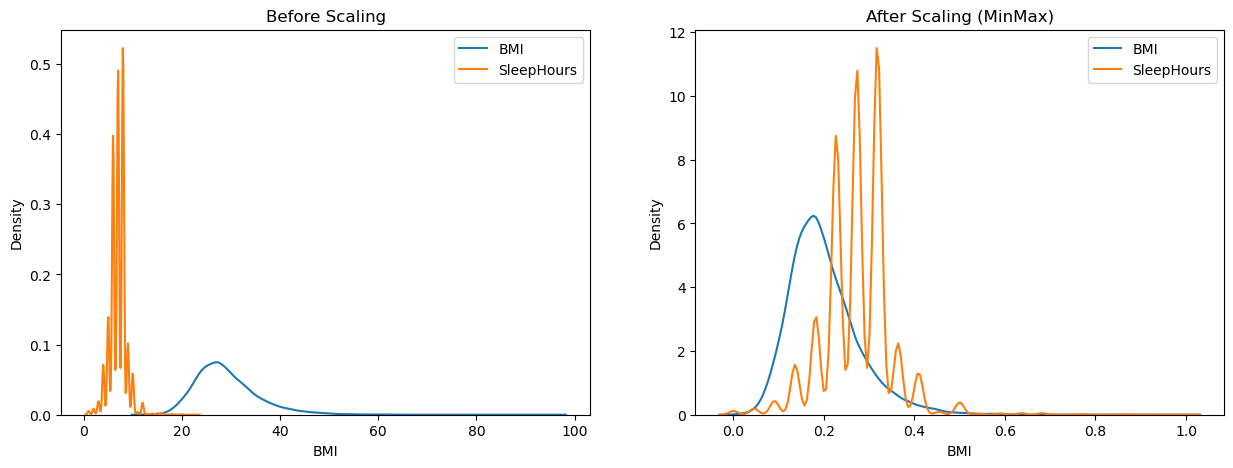

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

# Pick 3 numerical columns to check
cols_to_check = ['BMI', 'SleepHours']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Before Scaling
ax1.set_title('Before Scaling')
for col in cols_to_check:
    sns.kdeplot(Heart_encoded[col], ax=ax1, label=col)
ax1.legend()

# After Scaling
ax2.set_title('After Scaling (MinMax)')
for col in cols_to_check:
    sns.kdeplot(X_scaled[col], ax=ax2, label=col)
ax2.legend()

plt.show()

### Association Rule Mining
This step is to find out the ARM to understand the possible correlation between different features. It can help users to understand the different antecedent and consequent combination with different threshold of **support**, **confidence** and **lift**.

In [55]:
from mlxtend.frequent_patterns import fpgrowth, association_rules

To mine the ARM rules using FP-Growth. FP-Growth is used to find out the rules as it is a faster algorithm compared to apriori rule mining.

In [56]:
df_arm_encoded = Heart_encoded.drop(columns=['BMI', 'SleepHours'])
print(df_arm_encoded.shape)
frequent_itemsets = fpgrowth(df_arm_encoded, min_support=0.01, use_colnames=True)
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.2)
display(rules.head())


(26870, 34)


c:\anaconda3\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,"(SleepHours_Cat_> 7 Hours, Sex_Male)",(HadHeartAttack),0.218199,0.500000,0.134425,0.616067,1.232134,1.0,0.025326,1.302310,0.240982,0.230269,0.232134,0.442458
1,(HadHeartAttack),"(SleepHours_Cat_> 7 Hours, Sex_Male)",0.500000,0.218199,0.134425,0.268850,1.232134,1.0,0.025326,1.069276,0.376800,0.230269,0.064788,0.442458
2,(HadAngina_Yes),(HadHeartAttack),0.270190,0.500000,0.252028,0.932782,1.865565,1.0,0.116933,7.438525,0.635740,0.486389,0.865565,0.718419
3,(HadHeartAttack),(HadAngina_Yes),0.500000,0.270190,0.252028,0.504057,1.865565,1.0,0.116933,1.471559,0.927939,0.486389,0.320449,0.718419
4,(HadAngina_Yes),(Sex_Male),0.270190,0.554410,0.179978,0.666116,1.201485,1.0,0.030182,1.334564,0.229782,0.279199,0.250691,0.495372


Saving the finals rules to the local machine. This is performed so the streamlit can use the rules mined to display in the app without re-mining the rules. This will greatly improve the **User Experience** by pre-mined and speeding up the process.

In [57]:
import os
# 2. Define the exact path you want
save_path = os.getcwd() + "/heart_disease_rules.csv"

folder_path = os.path.dirname(save_path)
os.makedirs(folder_path, exist_ok=True)
print(f"Created folder structure at: {folder_path}")

# 3.Clean the antecedents and consequents (removes frozenset({}))
if 'rules' in locals():
    rules['antecedents'] = rules['antecedents'].apply(lambda x: ', '.join(list(x)) if isinstance(x, (set, frozenset)) else x)
    rules['consequents'] = rules['consequents'].apply(lambda x: ', '.join(list(x)) if isinstance(x, (set, frozenset)) else x)

    # 4. Save the file
    rules.to_csv(save_path, index=False)
    print(f"✅ Success! File saved to: {save_path}")
else:
    print(f"❌ Error: 'rules' dataframe is missing. Please run your association rules code first.")

Created folder structure at: c:\Users\edmun\Desktop\MMU\Degree\Sem 3\Data Mining\Project
✅ Success! File saved to: c:\Users\edmun\Desktop\MMU\Degree\Sem 3\Data Mining\Project/heart_disease_rules.csv


### Machine Learning Prediction
This step is to train Machine Learning Models for prediction. There are 4 models to be trained and they are:
1. SVM (Support Vector Machine)
2. Logistic Regression
3. Artificial Neural Network
4. Random Forest

Before training the models, we will be using *PCA* to reduce the feature count.
The model is then compared among each other for its accuracy and finally saved for the Interactive Application usage.

In [58]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. PCA
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# 2. Training (Updated to include Random Forest)
print("Training SVM...")
svm_model = SVC(kernel='rbf', C=1.0, probability=True, random_state=42)
svm_model.fit(X_train_pca, y_train)

print("Training Logistic Regression...")
logreg_model = LogisticRegression(max_iter=1000, random_state=42)
logreg_model.fit(X_train_pca, y_train)

print("Training ANN...")
ann_model = MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', max_iter=500, random_state=42)
ann_model.fit(X_train_pca, y_train)

print("Training Random Forest...") # Added model training
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_pca, y_train)

print("✅ All models trained successfully!")

# 3. Evaluation
from sklearn.metrics import classification_report, accuracy_score

models = {
    "SVM": svm_model,
    "Logistic Regression": logreg_model,
    "Artificial Neural Network": ann_model,
    "Random Forest": rf_model # Added to evaluation dictionary
}

best_model_name = ""
best_accuracy = 0

for name, model in models.items():
    y_pred = model.predict(X_test_pca)
    acc = accuracy_score(y_test, y_pred)
    print(f"\nModel: {name}")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))

    # Logic to track the most accurate model
    if acc > best_accuracy:
        best_accuracy = acc
        best_model_name = name

print(f"\n🏆 The most accurate model is: {best_model_name} with {best_accuracy:.4f} accuracy.")

Training SVM...
Training Logistic Regression...
Training ANN...
Training Random Forest...
✅ All models trained successfully!

Model: SVM
Accuracy: 0.7938
              precision    recall  f1-score   support

           0       0.77      0.83      0.80      2676
           1       0.82      0.76      0.79      2698

    accuracy                           0.79      5374
   macro avg       0.80      0.79      0.79      5374
weighted avg       0.80      0.79      0.79      5374


Model: Logistic Regression
Accuracy: 0.7882
              precision    recall  f1-score   support

           0       0.76      0.85      0.80      2676
           1       0.83      0.73      0.78      2698

    accuracy                           0.79      5374
   macro avg       0.79      0.79      0.79      5374
weighted avg       0.79      0.79      0.79      5374


Model: Artificial Neural Network
Accuracy: 0.7873
              precision    recall  f1-score   support

           0       0.78      0.79      0.

### Displaying Confusion Matrix
Confusion Matrix is one of the best way to visualize the accuracy of the model. Since the outcome is in Binary Format (Yes/No), this is the perfect way to display how 'confuse' is the model.

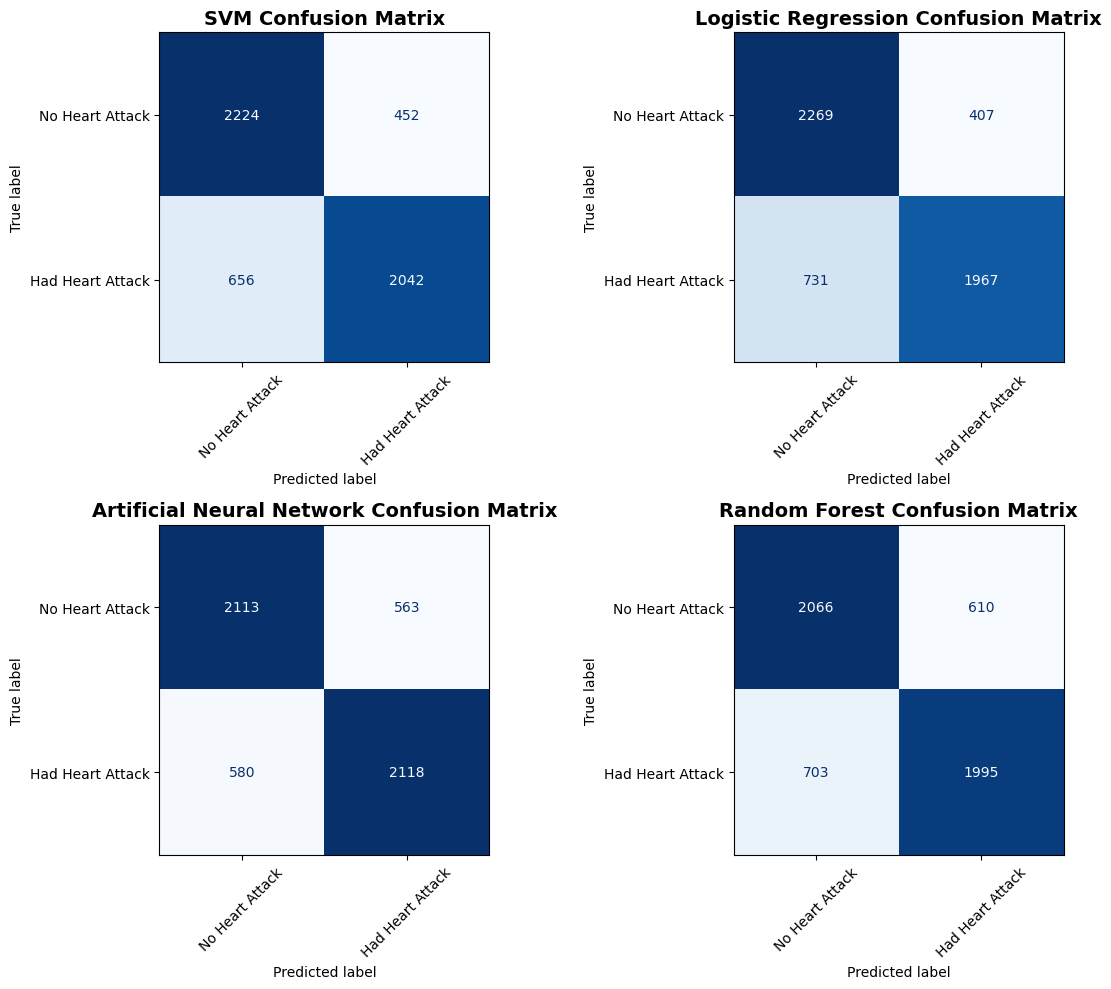

In [59]:
# Creating axes to plot confusion matrices
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes_flat = axes.flatten()

# Loop through models to plot confusion matrices
for i, (name, model) in enumerate(models.items()):
    # Get predictions
    y_pred = model.predict(X_test_pca)
    
    # Calculate confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    
    # Create the display object
    cm_display = ConfusionMatrixDisplay(
        confusion_matrix=cm, 
        display_labels=['No Heart Attack', 'Had Heart Attack']
    )
    
    # Plot onto the specific subplot
    cm_display.plot(
        ax=axes_flat[i], 
        cmap=plt.cm.Blues, 
        colorbar=False,
        xticks_rotation=45 # Rotates labels if they are too long
    )
    
    # Set the title for each subplot
    axes_flat[i].set_title(f'{name} Confusion Matrix', fontsize=14, fontweight='bold')

# 3. Clean up layout and display
plt.tight_layout()
plt.show()

Saving the model to local drive to be used in the streamlit app.

In [60]:
import os
import pickle

# 2. Set the path
save_path = os.getcwd() + "/heart_attack_pipeline.pkl"

# 3. Ensure directory exists
folder_path = os.path.dirname(save_path)
os.makedirs(folder_path, exist_ok=True)

# 4. Store ALL models and preprocessing objects
model_data = {
    'svm_model': svm_model,
    'logreg_model': logreg_model,
    'ann_model': ann_model,
    'rf_model': rf_model,
    'scaler': scaler,
    'pca_object': pca,
    'feature_names': X_train.columns.tolist()
}

# 5. Save using pickle
with open(save_path, 'wb') as f:
    pickle.dump(model_data, f)

print(f"✅ Success! All 4 models and preprocessing objects saved.")
print(f"Location: {save_path}")

✅ Success! All 4 models and preprocessing objects saved.
Location: c:\Users\edmun\Desktop\MMU\Degree\Sem 3\Data Mining\Project/heart_attack_pipeline.pkl
